In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv('Airlines.csv')

# Erste Übersicht
print("Anzahl Flüge:", len(df))
print("\nSpalten:")
print(df.columns.tolist())
print("\nErste 5 Zeilen:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Airlines.csv'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv('archive/Airlines.csv')

# Erste Übersicht
print("Anzahl Flüge:", len(df))
print("\nSpalten:")
print(df.columns.tolist())
print("\nErste 5 Zeilen:")
df.head()

Anzahl Flüge: 539383

Spalten:
['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

Erste 5 Zeilen:


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


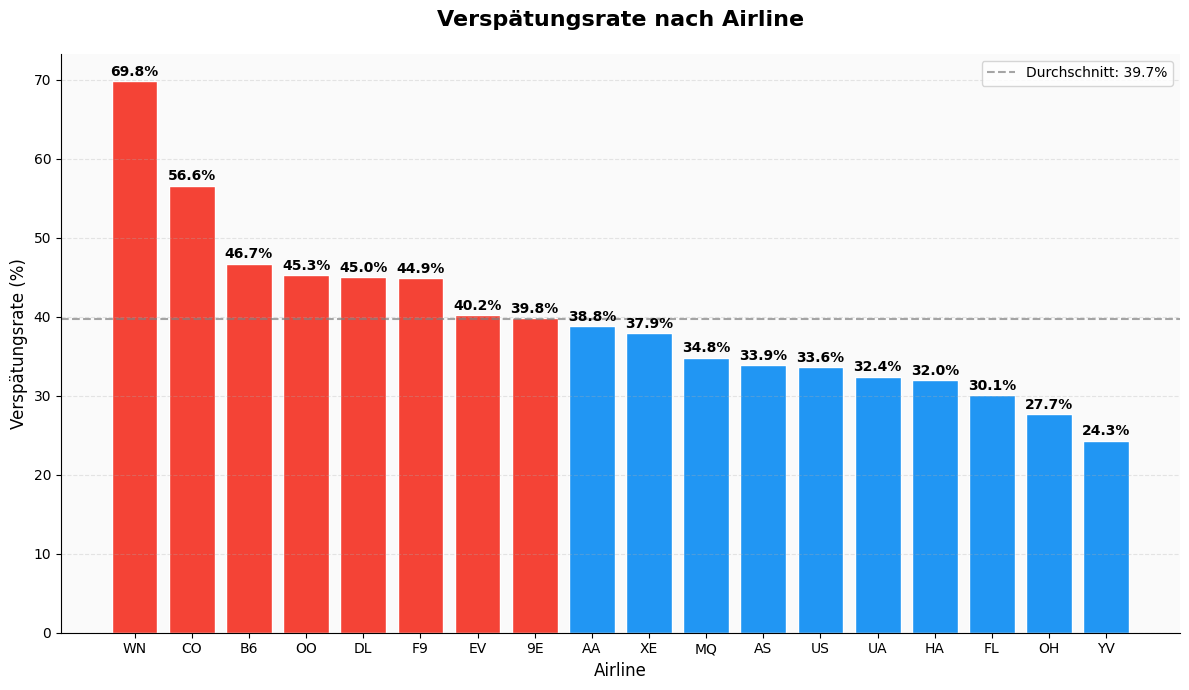

Gespeichert!


In [5]:
# Verspätungsrate nach Airline
verspaetung = df.groupby('Airline')['Delay'].mean() * 100
verspaetung = verspaetung.sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
farben = ['#F44336' if v > verspaetung.mean() else '#2196F3' for v in verspaetung.values]
balken = ax.bar(verspaetung.index, verspaetung.values, color=farben, edgecolor='white')

for b in balken:
    hoehe = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., hoehe + 0.3, f'{hoehe}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=verspaetung.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Durchschnitt: {verspaetung.mean():.1f}%')
ax.set_title('Verspätungsrate nach Airline', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Airline', fontsize=12)
ax.set_ylabel('Verspätungsrate (%)', fontsize=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('verspaetung_airline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

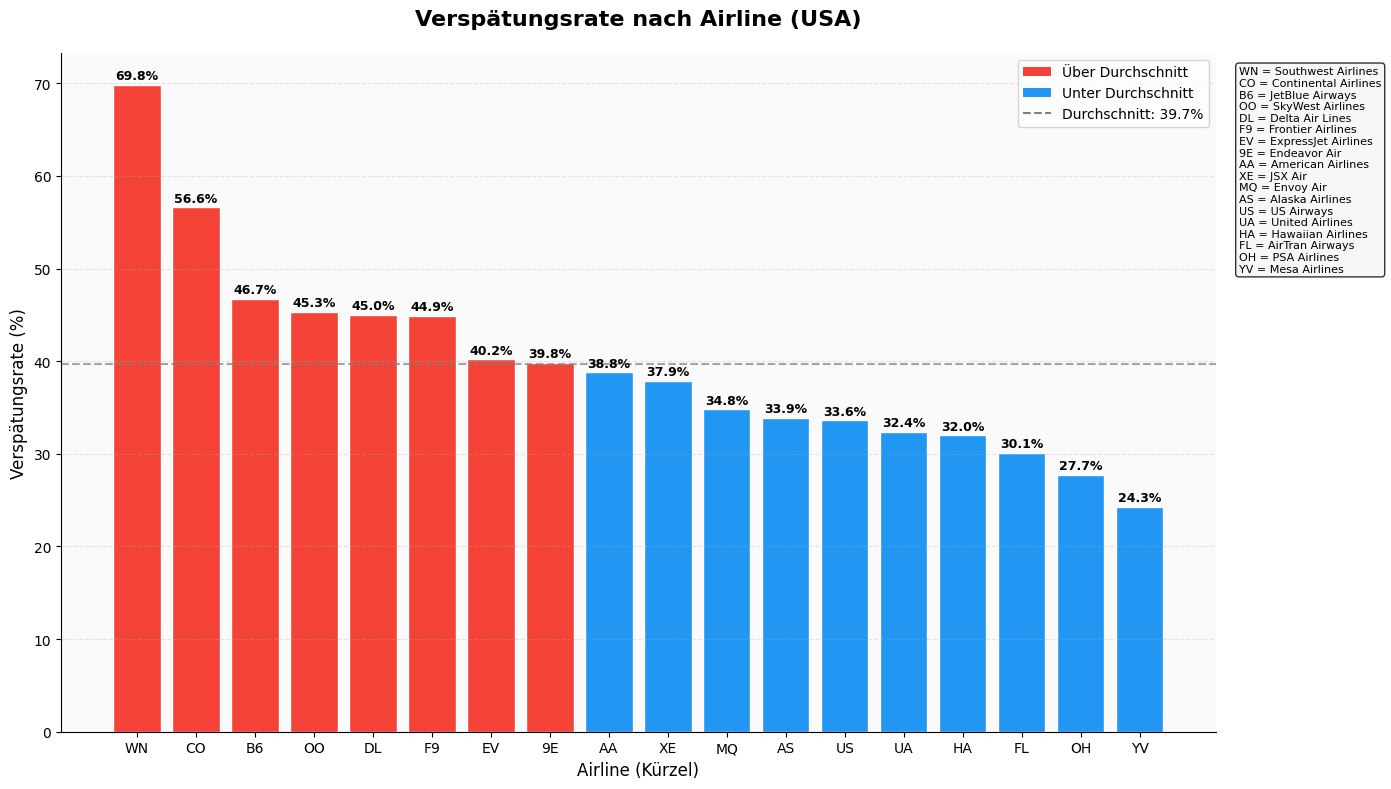

Gespeichert!


In [6]:
# Airline Namen für die Legende
airline_namen = {
    'WN': 'Southwest Airlines',
    'CO': 'Continental Airlines',
    'B6': 'JetBlue Airways',
    'OO': 'SkyWest Airlines',
    'DL': 'Delta Air Lines',
    'F9': 'Frontier Airlines',
    'EV': 'ExpressJet Airlines',
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'XE': 'JSX Air',
    'MQ': 'Envoy Air',
    'AS': 'Alaska Airlines',
    'US': 'US Airways',
    'UA': 'United Airlines',
    'HA': 'Hawaiian Airlines',
    'FL': 'AirTran Airways',
    'OH': 'PSA Airlines',
    'YV': 'Mesa Airlines'
}

verspaetung = df.groupby('Airline')['Delay'].mean() * 100
verspaetung = verspaetung.sort_values(ascending=False).round(1)

fig, ax = plt.subplots(figsize=(14, 8))
farben = ['#F44336' if v > verspaetung.mean() else '#2196F3' for v in verspaetung.values]
balken = ax.bar(verspaetung.index, verspaetung.values, color=farben, edgecolor='white')

for b in balken:
    hoehe = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., hoehe + 0.3, f'{hoehe}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(y=verspaetung.mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Durchschnitt: {verspaetung.mean():.1f}%')

# Legende für Airline Namen
legende_text = '\n'.join([f'{kuerzel} = {name}' for kuerzel, name in airline_namen.items() if kuerzel in verspaetung.index])
ax.text(1.02, 0.98, legende_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

from matplotlib.patches import Patch
legende_elemente = [
    Patch(facecolor='#F44336', label='Über Durchschnitt'),
    Patch(facecolor='#2196F3', label='Unter Durchschnitt'),
]
ax.legend(handles=legende_elemente + [plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Durchschnitt: {verspaetung.mean():.1f}%')],
          loc='upper right')

ax.set_title('Verspätungsrate nach Airline (USA)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Airline (Kürzel)', fontsize=12)
ax.set_ylabel('Verspätungsrate (%)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('verspaetung_airline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

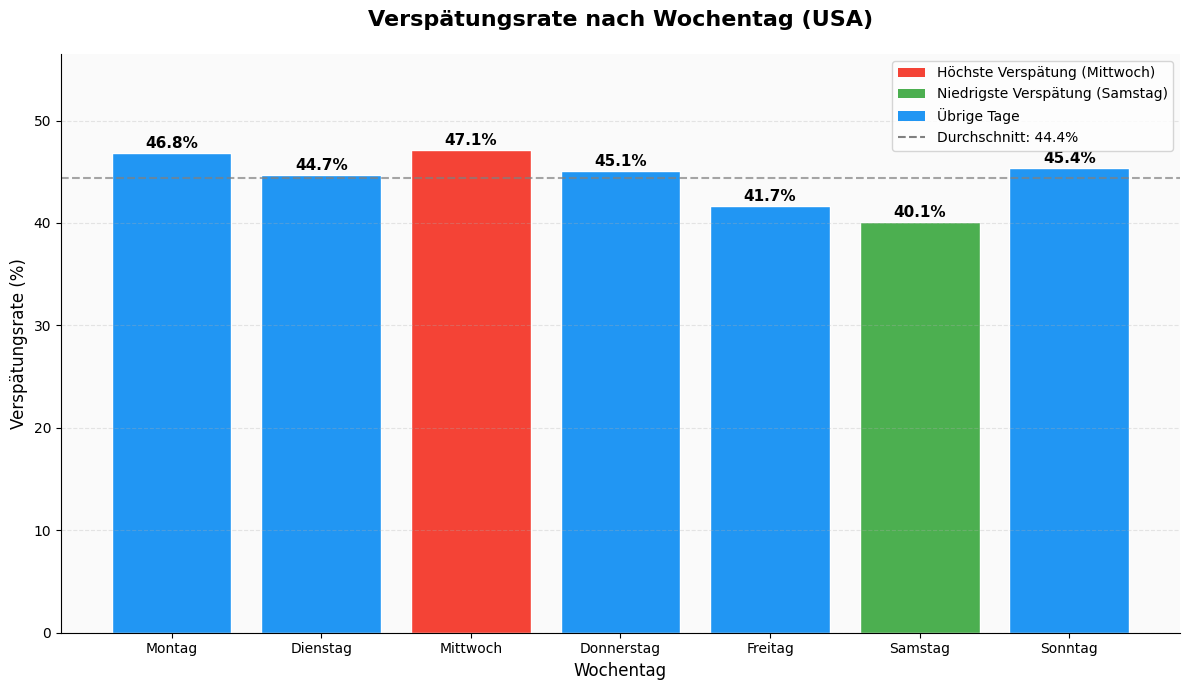

Gespeichert!


In [7]:
# Verspätungsrate nach Wochentag
wochentage = {1: 'Montag', 2: 'Dienstag', 3: 'Mittwoch', 
              4: 'Donnerstag', 5: 'Freitag', 6: 'Samstag', 7: 'Sonntag'}
df['Tag'] = df['DayOfWeek'].map(wochentage)
reihenfolge = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

tag_verspaetung = df.groupby('Tag')['Delay'].mean() * 100
tag_verspaetung = tag_verspaetung.reindex(reihenfolge).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
min_tag = tag_verspaetung.idxmin()
max_tag = tag_verspaetung.idxmax()
farben = []
for tag in reihenfolge:
    if tag == max_tag:
        farben.append('#F44336')
    elif tag == min_tag:
        farben.append('#4CAF50')
    else:
        farben.append('#2196F3')

balken = ax.bar(reihenfolge, tag_verspaetung.values, color=farben, edgecolor='white')

for b in balken:
    hoehe = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., hoehe + 0.2, f'{hoehe}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=tag_verspaetung.mean(), color='gray', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legende_elemente = [
    Patch(facecolor='#F44336', label=f'Höchste Verspätung ({max_tag})'),
    Patch(facecolor='#4CAF50', label=f'Niedrigste Verspätung ({min_tag})'),
    Patch(facecolor='#2196F3', label='Übrige Tage'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Durchschnitt: {tag_verspaetung.mean():.1f}%')
]
ax.legend(handles=legende_elemente, loc='upper right')

ax.set_title('Verspätungsrate nach Wochentag (USA)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Wochentag', fontsize=12)
ax.set_ylabel('Verspätungsrate (%)', fontsize=12)
ax.set_ylim(0, tag_verspaetung.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('verspaetung_wochentag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

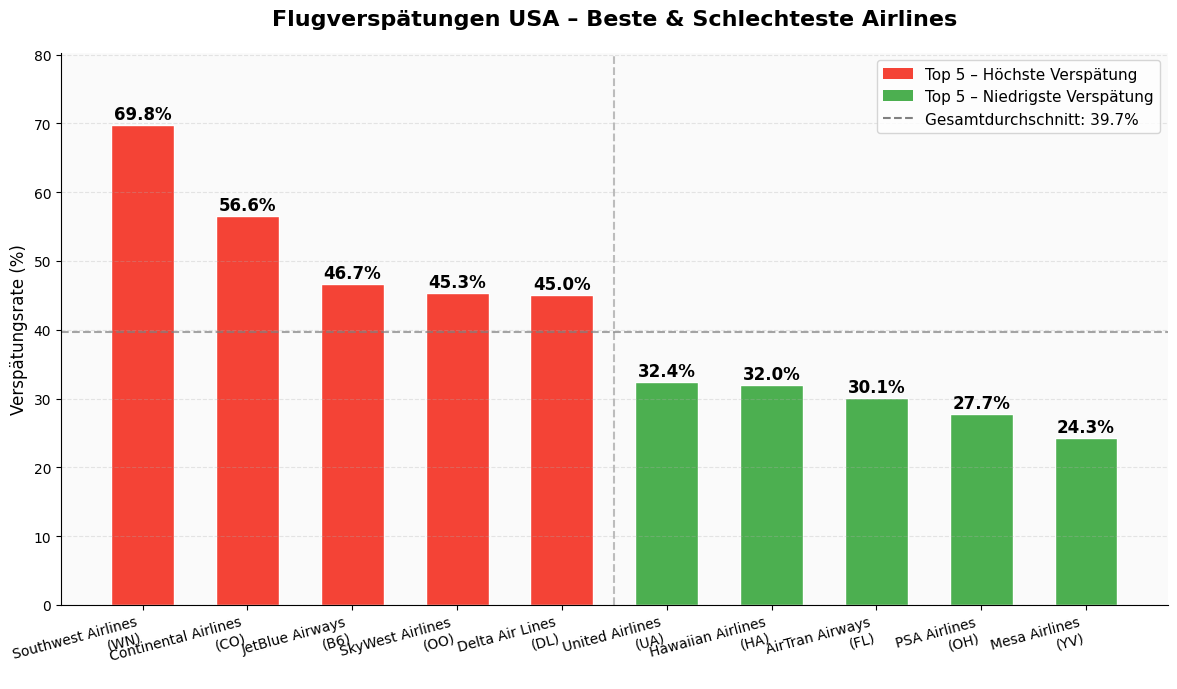

Gespeichert!


In [9]:
# Top 5 und Bottom 5 Airlines
verspaetung = df.groupby('Airline')['Delay'].mean() * 100
verspaetung = verspaetung.sort_values(ascending=False).round(1)

airline_namen = {
    'WN': 'Southwest Airlines',
    'CO': 'Continental Airlines',
    'B6': 'JetBlue Airways',
    'OO': 'SkyWest Airlines',
    'DL': 'Delta Air Lines',
    'F9': 'Frontier Airlines',
    'EV': 'ExpressJet Airlines',
    '9E': 'Endeavor Air',
    'AA': 'American Airlines',
    'XE': 'JSX Air',
    'MQ': 'Envoy Air',
    'AS': 'Alaska Airlines',
    'US': 'US Airways',
    'UA': 'United Airlines',
    'HA': 'Hawaiian Airlines',
    'FL': 'AirTran Airways',
    'OH': 'PSA Airlines',
    'YV': 'Mesa Airlines'
}

top5 = verspaetung.head(5)
bottom5 = verspaetung.tail(5)
auswahl = pd.concat([top5, bottom5])
labels = [f"{airline_namen.get(k, k)}\n({k})" for k in auswahl.index]

farben = ['#F44336'] * 5 + ['#4CAF50'] * 5

fig, ax = plt.subplots(figsize=(12, 7))
balken = ax.bar(range(len(auswahl)), auswahl.values, color=farben, edgecolor='white', width=0.6)

for i, b in enumerate(balken):
    hoehe = b.get_height()
    ax.text(b.get_x() + b.get_width()/2., hoehe + 0.3, f'{hoehe}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xticks(range(len(auswahl)))
ax.set_xticklabels(labels, fontsize=10, rotation=15, ha='right')
ax.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=verspaetung.mean(), color='gray', linestyle='--', alpha=0.7)

from matplotlib.patches import Patch
legende_elemente = [
    Patch(facecolor='#F44336', label='Top 5 – Höchste Verspätung'),
    Patch(facecolor='#4CAF50', label='Top 5 – Niedrigste Verspätung'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Gesamtdurchschnitt: {verspaetung.mean():.1f}%')
]
ax.legend(handles=legende_elemente, loc='upper right', fontsize=11)

ax.set_title('Flugverspätungen USA – Beste & Schlechteste Airlines', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Verspätungsrate (%)', fontsize=12)
ax.set_ylim(0, auswahl.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('verspaetung_airline_top_bottom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")